# Notebook di test dei metodi implementati

In [1]:
import sys
sys.path.append('..')

from portfolio import Portfolio, plot_efficient_frontier
from backtesting.cppi import CPPI
from backtesting.singleasset import SMA, Bollinger, Momentum
from matplotlib import pyplot as plt
from marketdata.fmp import FMPProvider

%load_ext autoreload
%autoreload 2

## Classe Tickers

[*********************100%***********************]  6 of 6 completed


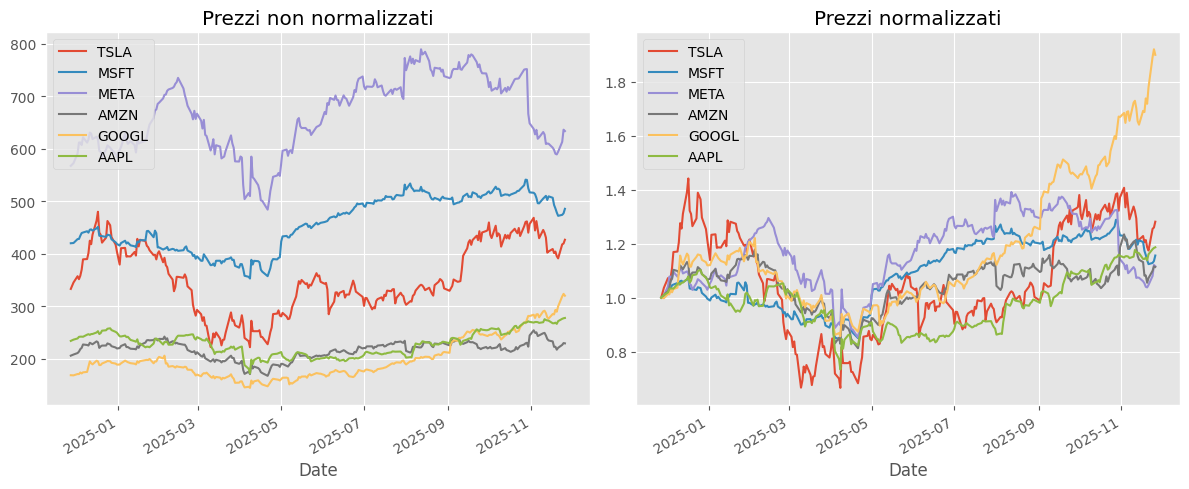

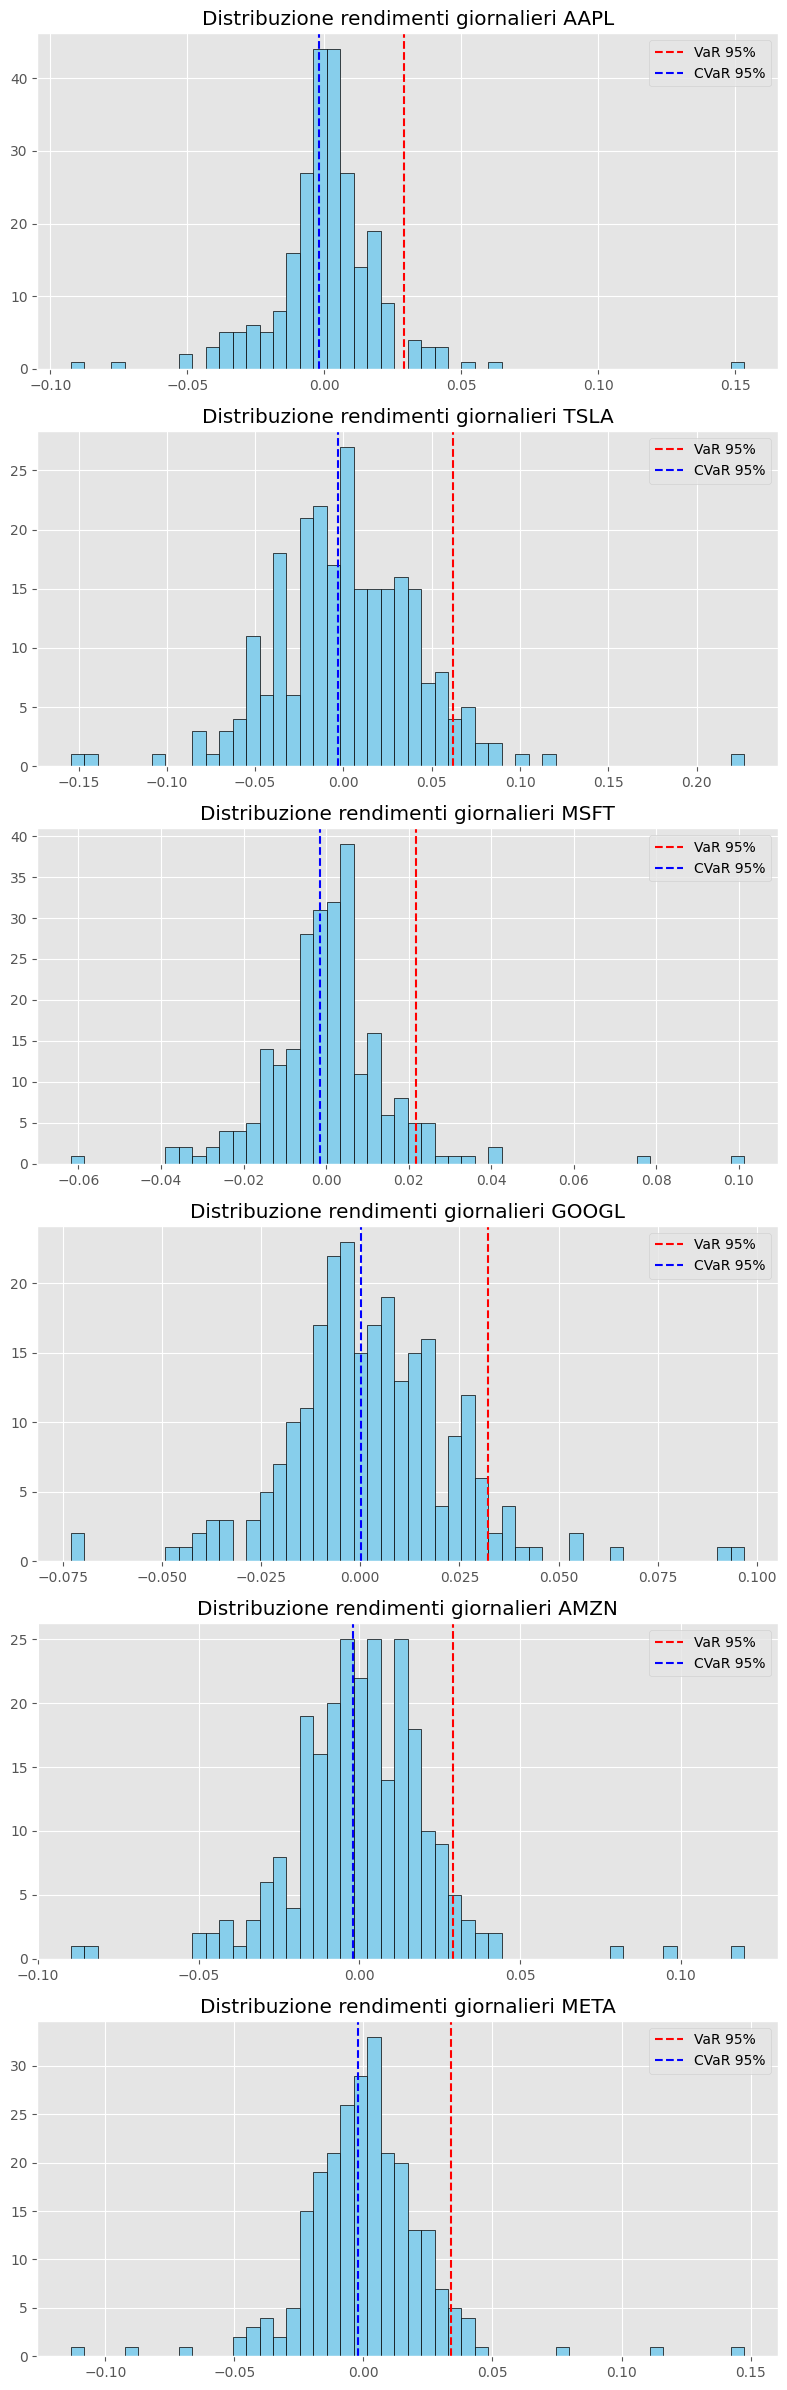

,Annual Returns,Annual Volatility,Max Drawdown,Sharpe Ratio,VaR (95%),VaR Cornish-Fischer (95%),CVaR (95%)
TSLA,0.282527,0.654619,0.775031,0.385762,-0.061865,-0.072615,0.003055
MSFT,0.156820,0.243463,0.234495,0.520902,-0.021875,-0.026095,0.001372
META,0.117079,0.383777,0.442343,0.226900,-0.033964,-0.040610,0.002310
AMZN,0.114242,0.349483,0.363274,0.241048,-0.029064,-0.033028,0.002076
GOOGL,0.903113,0.333162,0.363906,2.620686,-0.032328,-0.044444,-0.000149
AAPL,0.187451,0.326670,0.367813,0.481990,-0.029187,-0.037303,0.001753


In [2]:
from portfolio import Tickers

# classe istanziata fornendo una lista di asset, un periodo ed eventualmente un provider di dati
titoli = ['AAPL', 'TSLA', 'MSFT', 'GOOGL', 'AMZN', 'META']
dict_tickers = {"tickers": titoli, 'period': '1y'}
tickers_yf = Tickers(**dict_tickers)

# test plot (prezzi normalizzati e non)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
tickers_yf.plot(rescale=False, ax=ax1, title="Prezzi non normalizzati")
tickers_yf.plot(rescale=True, ax=ax2, title="Prezzi normalizzati")
fig.tight_layout()

tickers_yf.plot_dailyret_dist()

# test _repr_html_
tickers_yf

## Classe Portfolio

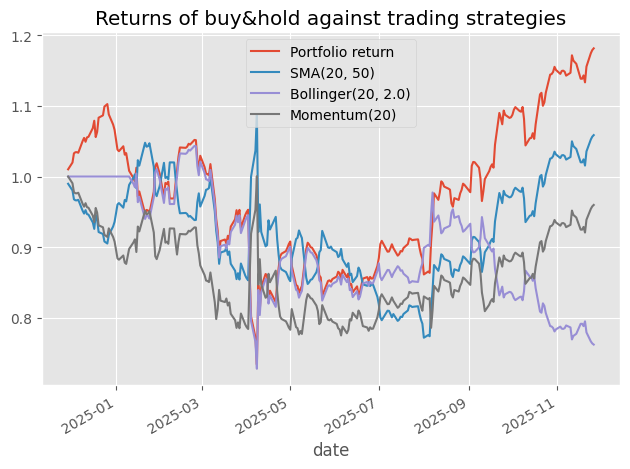

In [2]:
call_eur_usd = {"tickers": "AAPL", 'period': '1y'}
eur_usd = Tickers(**call_eur_usd, provider=FMPProvider())

SMA(eur_usd).plot()
Bollinger(eur_usd).plot()
Momentum(eur_usd).plot()
plt.tight_layout()

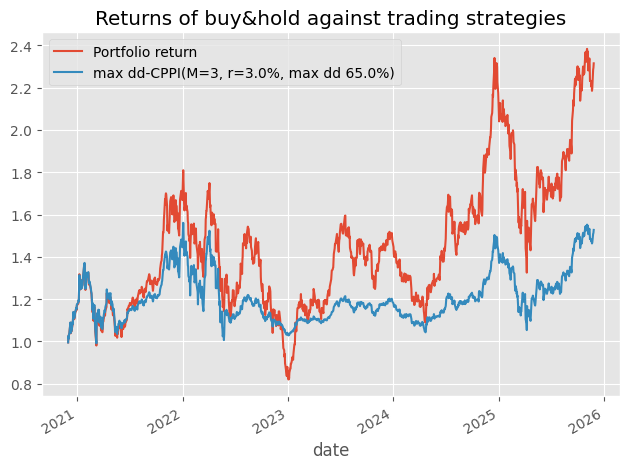

In [2]:
sp_500 = {
    'tickers': ['AAPL', 'TSLA'],
    'period': '5y'
}
ew = Portfolio(Tickers(**sp_500, provider=FMPProvider()))
CPPI(ew, floor=0.65, reb='6M', type='max dd').plot()
plt.tight_layout()

[*********************100%***********************]  2 of 2 completed


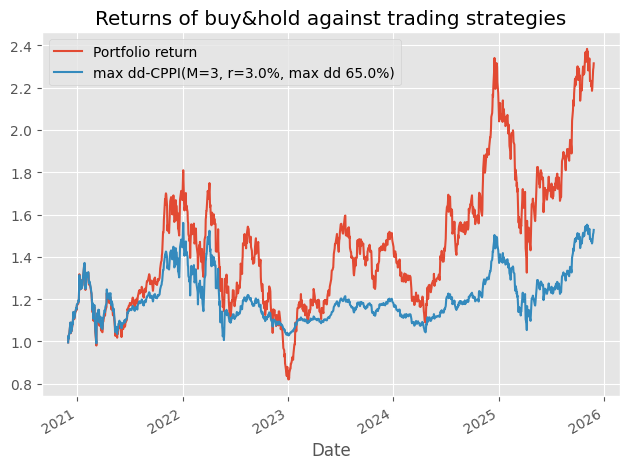

In [5]:
sp_500 = {
    'tickers': ['AAPL', 'TSLA'],
    'period': '5y'
}
ew = Portfolio(Tickers(**sp_500))
CPPI(ew, floor=0.65, reb='6M', type='max dd').plot()
plt.tight_layout()

In [3]:
sp_500 = {
    'tickers': ['AAPL', 'TSLA'],
    'period': '5y'
}
ew = Portfolio(Tickers(**sp_500))
plot_ef_cml([ew, ew.gmv(), ew.msr(rf=0.03)], rf_ratio=0.03)

[*********************100%***********************]  2 of 2 completed


AttributeError: 'Portfolio' object has no attribute 'copy'